https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine


In [56]:
from sklearn.datasets import load_wine

data = load_wine()
x = data.data
y = data.target

print(data.feature_names)
print(data.target_names)

print(data.DESCR)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']
.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11

In [57]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler


def heat_map(data, model):
    x = data.data
    y = data.target
    X_treino, X_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)

    model.fit(X_treino, y_treino)
    y_pred = model.predict(X_teste)

    cm = confusion_matrix(y_teste,y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=data.target_names,
        yticklabels=data.target_names
    )

    plt.show()

def cross_validation(data, model):
    x = data.data
    y = data.target
    Acuracia_score = []
    F1_score = []
    kf = KFold(n_splits=5)

    for i, (train_index, test_index) in enumerate(kf.split(x)):
        model.fit(x[train_index], y[train_index])
        y_pred = model.predict(x[test_index])

        Acuracia_score.append(accuracy_score(y[test_index],y_pred))
        F1_score.append(f1_score(y[test_index],y_pred,average="macro"))

    print(f"""Acuracia: {np.mean(Acuracia_score)}\nF1 Score: {np.mean(F1_score)}""")
    
def heat_map_normalizer(data, model):
    scaler = MinMaxScaler()
    x = data.data
    y = data.target
    X_treino, X_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)

    X_treino_normalizer = scaler.fit_transform(X_treino)
    X_teste_normalizer = scaler.transform(X_teste)
    
    model.fit(X_treino_normalizer, y_treino)
    y_pred = model.predict(X_teste_normalizer)

    cm = confusion_matrix(y_teste,y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=data.target_names,
        yticklabels=data.target_names
    )

    plt.show()


def cross_validation_normalizer(data, model):
    x = data.data
    y = data.target
    Acuracia_score = []
    F1_score = []
    kf = KFold(n_splits=5)

    for i, (train_index, test_index) in enumerate(kf.split(x)):
        scaler = MinMaxScaler()

        model.fit(scaler.fit_transform(x[train_index]), y[train_index])
        y_pred = model.predict(scaler.transform(x[test_index]))

        Acuracia_score.append(accuracy_score(y[test_index],y_pred))
        F1_score.append(f1_score(y[test_index],y_pred,average="macro"))

    print(f"""Acuracia: {np.mean(Acuracia_score)}\nF1 Score: {np.mean(F1_score)}""")
    

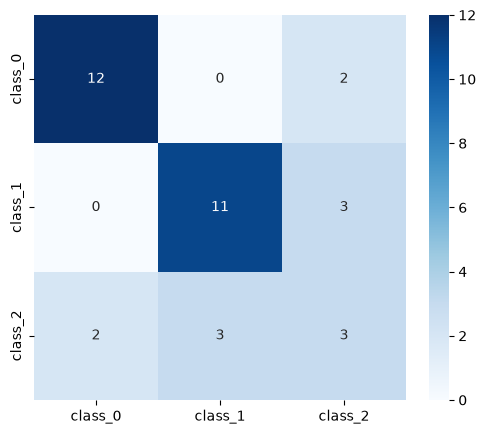

Acuracia: 0.61
F1 Score: 0.361325431955843


-----------------------------
AGORA COM DADOS NORMALIZADOS
-----------------------------




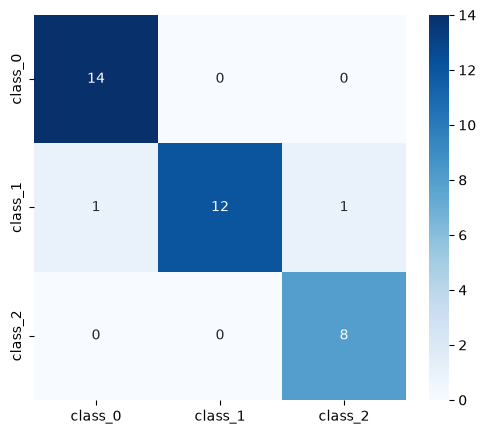

Acuracia: 0.9049206349206349
F1 Score: 0.49855763115651897


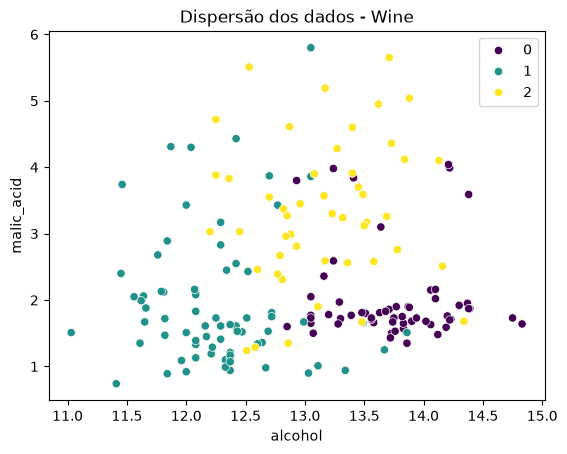

In [59]:
from sklearn.neighbors import KNeighborsClassifier


model = KNeighborsClassifier(n_neighbors=5)
heat_map(data=data,model=model)
cross_validation(data=data,model=model)
print("\n")
print("-----------------------------")
print("AGORA COM DADOS NORMALIZADOS")
print("-----------------------------")
print("\n")
heat_map_normalizer(data=data,model=model)
cross_validation_normalizer(data=data,model=model)



sns.scatterplot(
    x=data.data[:, 0],
    y=data.data[:, 1],
    hue=data.target,
    palette="viridis"
)

plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Dispersão dos dados - Wine")
plt.show()

Como as features possuem escalas diferentes, algumas variáveis podem acabar influenciando mais o modelo devido aos seus valores maiores. Para evitar essa diferença de escala, será utilizado o **MinMaxScaler**, que coloca todas as features em uma mesma escala, permitindo uma contribuição mais equilibrada de cada variável.

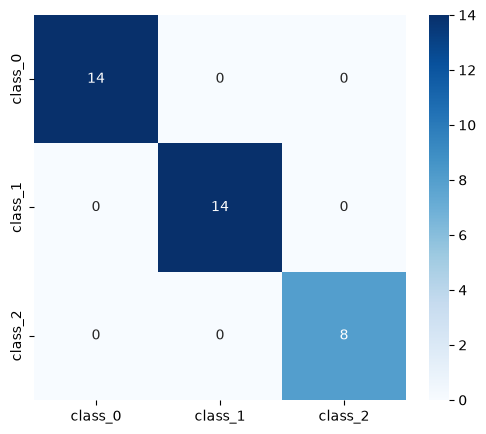

Acuracia: 0.9553968253968254
F1 Score: 0.5856884500362761


-----------------------------
AGORA COM DADOS NORMALIZADOS
-----------------------------




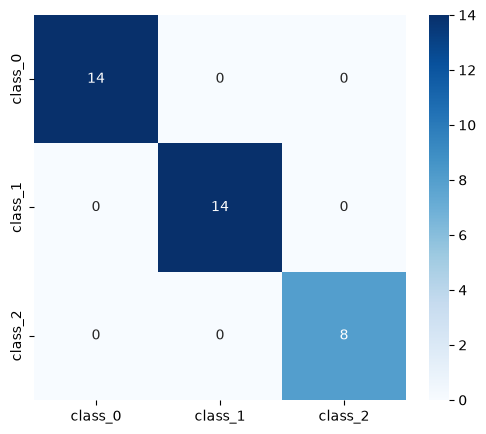

Acuracia: 0.9609523809523809
F1 Score: 0.589631469979296


In [60]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
heat_map(data=data,model=model)
cross_validation(data=data,model=model)
print("\n")
print("-----------------------------")
print("AGORA COM DADOS NORMALIZADOS")
print("-----------------------------")
print("\n")
heat_map_normalizer(data=data,model=model)
cross_validation_normalizer(data=data,model=model)

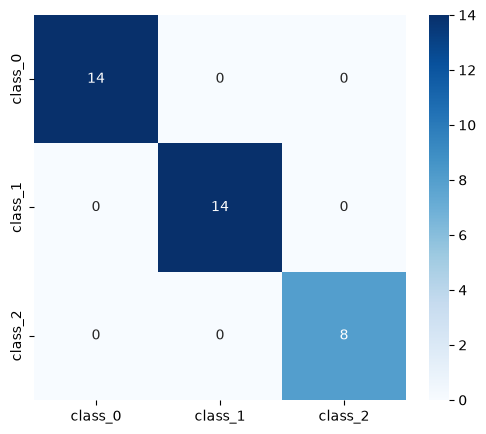

Acuracia: 0.9385714285714286
F1 Score: 0.673493890309747


-----------------------------
AGORA COM DADOS NORMALIZADOS
-----------------------------




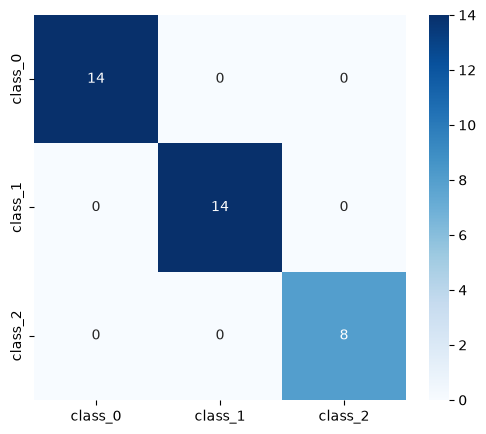

Acuracia: 0.9274603174603173
F1 Score: 0.5724857836421756


In [61]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=100000)
heat_map(data=data,model=model)
cross_validation(data=data,model=model)
print("\n")
print("-----------------------------")
print("AGORA COM DADOS NORMALIZADOS")
print("-----------------------------")
print("\n")
heat_map_normalizer(data=data,model=model)
cross_validation_normalizer(data=data,model=model)